# Train DCGAN + Test Density/Coverage

This notebook:
- loads CIFAR-10 with `UnifiedDatasetLoader`
- trains `DCGANGenerator` and `DCGANDiscriminator`
- saves checkpoints
- generates fake images
- extracts InceptionV3 features
- computes density and coverage

In [57]:
from __future__ import annotations

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import models, transforms

CURRENT = Path.cwd().resolve()
if (CURRENT / "Datasets").exists():
    REPO_ROOT = CURRENT
elif (CURRENT.parent / "Datasets").exists():
    REPO_ROOT = CURRENT.parent
else:
    raise RuntimeError("Could not locate repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Datasets.dataset_subset import DatasetSubsetConfig
from Datasets.unified_dataset_loader import DatasetConfig, UnifiedDatasetLoader
from Models.dcgan import DCGANGenerator, DCGANDiscriminator, dcgan_weights_init
from Metrics.density_coverage import compute_density_coverage

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("REPO_ROOT:", REPO_ROOT)
print("device:", device)

REPO_ROOT: C:\Users\aggel\OneDrive\Υπολογιστής\Group07_Improving_Metrics
device: cuda


In [58]:
DATASET_NAME = "cifar10"
DATA_ROOT = str(REPO_ROOT / "data" / "CIFAR10")

IMAGE_SIZE = 32
BATCH_SIZE = 128
NUM_WORKERS = 0
SEED = 42

LATENT_DIM = 100
NGF = 64
NDF = 64
LR = 2e-4
BETA1 = 0.5
NUM_EPOCHS = 5   # start small; increase later

REAL_SUBSET_SIZE = 500
FAKE_BATCH_SIZE = 32
FAKE_NUM_BATCHES = 16
K = 5

OUTPUT_DIR = REPO_ROOT / "outputs" / "dcgan_cifar10"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NETG_LATEST = OUTPUT_DIR / "netG_latest.pth"
NETD_LATEST = OUTPUT_DIR / "netD_latest.pth"

torch.manual_seed(SEED)
np.random.seed(SEED)

In [59]:
subset_cfg = DatasetSubsetConfig(
    max_samples=None,
    fraction=None,
    seed=SEED,
    strategy="random",
)

loader_cfg = DatasetConfig(
    name=DATASET_NAME,
    data_root=DATA_ROOT,
    image_size=IMAGE_SIZE,
    normalize_to_neg_one_one=True,
    subset_config=subset_cfg,
)

unified_loader = UnifiedDatasetLoader(loader_cfg)

try:
    train_ds = unified_loader.get_dataset(train=True, download=False)
except (FileNotFoundError, RuntimeError) as exc:
    print(f"Dataset missing/incomplete ({exc}); trying download...")
    train_ds = unified_loader.get_dataset(train=True, download=True)

print("Train dataset size:", len(train_ds))
class_names = list(getattr(train_ds, "classes", []))
if class_names:
    print("Classes:", class_names)

Train dataset size: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


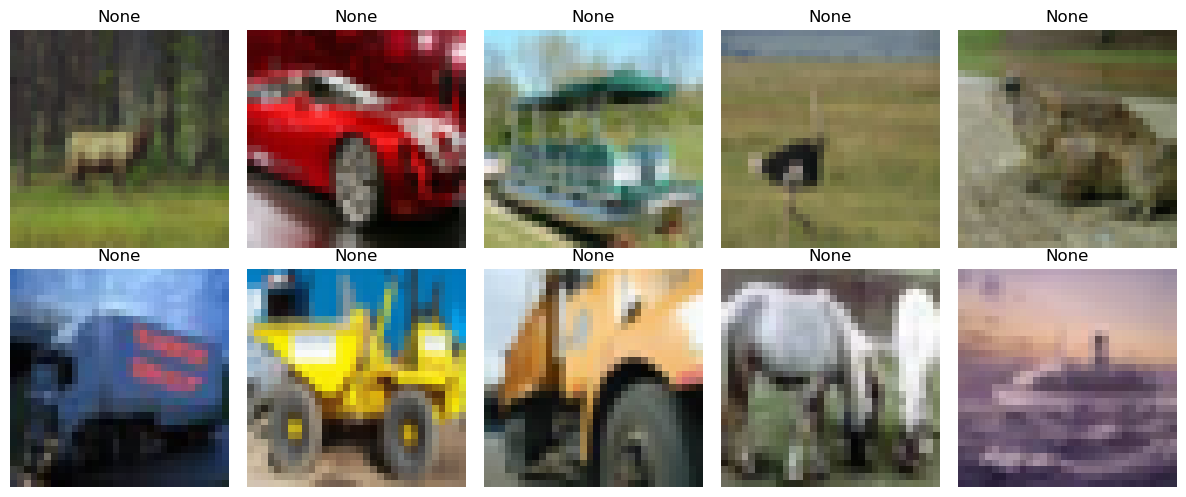

In [60]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(train_ds), size=min(10, len(train_ds)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_indices):
    image, label = train_ds[int(idx)]
    img = ((image.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)
    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    label_idx = int(label.item()) if isinstance(label, torch.Tensor) and label.ndim == 0 else None
    title = class_names[label_idx] if label_idx is not None and class_names else str(label_idx)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [61]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

sample_x, _ = train_ds[0]
num_channels = int(sample_x.shape[0])
print("num_channels:", num_channels)

num_channels: 3


In [62]:
netG = DCGANGenerator(
    ngpu=0,
    nc=num_channels,
    nz=LATENT_DIM,
    ngf=NGF,
    image_size=IMAGE_SIZE,
).to(device)

netD = DCGANDiscriminator(
    ngpu=0,
    nc=num_channels,
    ndf=NDF,
    image_size=IMAGE_SIZE,
).to(device)

netG.apply(dcgan_weights_init)
netD.apply(dcgan_weights_init)

print(netG)
print(netD)

DCGANGenerator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)
DCGA

In [63]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

fixed_noise = torch.randn(25, LATENT_DIM, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0

In [64]:
G_losses = []
D_losses = []
img_list = []

for epoch in range(NUM_EPOCHS):
    for i, batch in enumerate(train_loader):
        real_images = batch[0].to(device)
        b_size = real_images.size(0)

        # -----------------
        # Train D
        # -----------------
        netD.zero_grad()

        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output_real = netD(real_images)
        errD_real = criterion(output_real, label)
        errD_real.backward()
        D_x = output_real.mean().item()

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output_fake = netD(fake.detach())
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()
        D_G_z1 = output_fake.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # -----------------
        # Train G
        # -----------------
        netG.zero_grad()
        label.fill_(real_label)
        output_fake_for_G = netD(fake)
        errG = criterion(output_fake_for_G, label)
        errG.backward()
        D_G_z2 = output_fake_for_G.mean().item()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 100 == 0:
            print(
                f"[{epoch+1}/{NUM_EPOCHS}] "
                f"[{i}/{len(train_loader)}] "
                f"Loss_D: {errD.item():.4f} "
                f"Loss_G: {errG.item():.4f} "
                f"D(x): {D_x:.4f} "
                f"D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}"
            )

    with torch.no_grad():
        fake_fixed = netG(fixed_noise).detach().cpu()
    img_list.append(fake_fixed)

    torch.save(netG.state_dict(), NETG_LATEST)
    torch.save(netD.state_dict(), NETD_LATEST)
    torch.save(netG.state_dict(), OUTPUT_DIR / f"netG_epoch_{epoch+1}.pth")
    torch.save(netD.state_dict(), OUTPUT_DIR / f"netD_epoch_{epoch+1}.pth")

    print(f"Saved checkpoints for epoch {epoch+1}")

[1/5] [0/390] Loss_D: 1.3608 Loss_G: 2.3261 D(x): 0.4387 D(G(z)): 0.3520/0.1130
[1/5] [100/390] Loss_D: 0.2734 Loss_G: 4.3950 D(x): 0.8588 D(G(z)): 0.0816/0.0142
[1/5] [200/390] Loss_D: 0.8713 Loss_G: 2.2234 D(x): 0.5942 D(G(z)): 0.2369/0.1274
[1/5] [300/390] Loss_D: 0.2778 Loss_G: 3.7403 D(x): 0.8698 D(G(z)): 0.0988/0.0303
Saved checkpoints for epoch 1
[2/5] [0/390] Loss_D: 0.7707 Loss_G: 2.3481 D(x): 0.7512 D(G(z)): 0.3450/0.1117
[2/5] [100/390] Loss_D: 1.0071 Loss_G: 2.2243 D(x): 0.5844 D(G(z)): 0.3003/0.1277
[2/5] [200/390] Loss_D: 0.3735 Loss_G: 3.5463 D(x): 0.7699 D(G(z)): 0.0678/0.0445
[2/5] [300/390] Loss_D: 1.1472 Loss_G: 1.9408 D(x): 0.6110 D(G(z)): 0.4095/0.1728
Saved checkpoints for epoch 2
[3/5] [0/390] Loss_D: 0.9368 Loss_G: 2.8971 D(x): 0.5894 D(G(z)): 0.2263/0.0873
[3/5] [100/390] Loss_D: 0.5899 Loss_G: 2.4011 D(x): 0.6706 D(G(z)): 0.1130/0.1115
[3/5] [200/390] Loss_D: 0.4533 Loss_G: 2.5417 D(x): 0.7666 D(G(z)): 0.1288/0.1037
[3/5] [300/390] Loss_D: 1.0019 Loss_G: 3.339

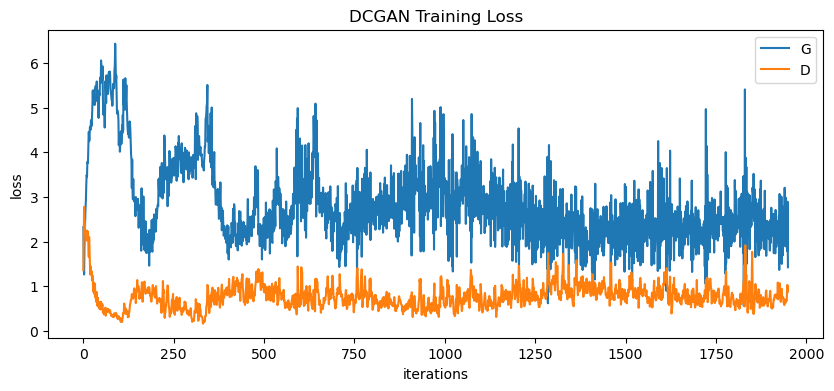

In [65]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("loss")
plt.title("DCGAN Training Loss")
plt.legend()
plt.show()

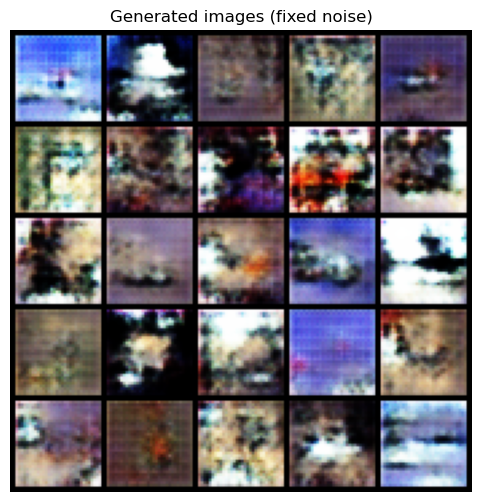

In [66]:
final_fake = img_list[-1]

grid = torchvision.utils.make_grid(((final_fake + 1.0) / 2.0).clamp(0, 1), nrow=5)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Generated images (fixed noise)")
plt.show()

In [67]:
real_subset_size = min(REAL_SUBSET_SIZE, len(train_ds))
real_indices = np.random.default_rng(SEED).choice(len(train_ds), size=real_subset_size, replace=False)
real_sampler = SubsetRandomSampler(real_indices.tolist())

real_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=real_sampler,
    num_workers=0,
)

print("Real subset size:", real_subset_size)

Real subset size: 500


In [68]:
inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
inception.fc = nn.Identity()
inception.aux_logits = False
inception.eval().to(device)

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
resize_299 = transforms.Resize((299, 299))

In [69]:
def prepare_for_inception(images: torch.Tensor) -> torch.Tensor:
    x = images.to(device)
    if x.ndim != 4:
        raise ValueError("Expected BCHW tensor.")
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    x = ((x + 1.0) / 2.0).clamp(0.0, 1.0)   # [-1,1] -> [0,1]
    x = resize_299(x)
    x = (x - imagenet_mean) / imagenet_std
    return x

In [70]:
def extract_features_from_loader(loader: DataLoader) -> np.ndarray:
    features = []
    with torch.no_grad():
        for batch in loader:
            images = batch[0] if isinstance(batch, (tuple, list)) else batch
            processed = prepare_for_inception(images)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())
    return np.concatenate(features, axis=0)


def extract_features_from_generator(generator_model: torch.nn.Module, num_batches: int, batch_size: int) -> tuple[np.ndarray, torch.Tensor]:
    features = []
    generated_images = []

    with torch.no_grad():
        for _ in range(num_batches):
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake = generator_model(z)
            generated_images.append(fake.detach().cpu())

            processed = prepare_for_inception(fake)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())

    return np.concatenate(features, axis=0), torch.cat(generated_images, dim=0)


def extract_features_from_noise(num_batches: int, batch_size: int, channels: int) -> np.ndarray:
    features = []
    with torch.no_grad():
        for _ in range(num_batches):
            noise_imgs = torch.rand(batch_size, channels, IMAGE_SIZE, IMAGE_SIZE, device=device) * 2.0 - 1.0
            processed = prepare_for_inception(noise_imgs)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())
    return np.concatenate(features, axis=0)

In [71]:
def extract_features_from_loader(loader: DataLoader) -> np.ndarray:
    features = []
    with torch.no_grad():
        for batch in loader:
            images = batch[0] if isinstance(batch, (tuple, list)) else batch
            processed = prepare_for_inception(images)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())
    return np.concatenate(features, axis=0)


def extract_features_from_generator(generator_model: torch.nn.Module, num_batches: int, batch_size: int) -> tuple[np.ndarray, torch.Tensor]:
    features = []
    generated_images = []

    with torch.no_grad():
        for _ in range(num_batches):
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake = generator_model(z)
            generated_images.append(fake.detach().cpu())

            processed = prepare_for_inception(fake)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())

    return np.concatenate(features, axis=0), torch.cat(generated_images, dim=0)


def extract_features_from_noise(num_batches: int, batch_size: int, channels: int) -> np.ndarray:
    features = []
    with torch.no_grad():
        for _ in range(num_batches):
            noise_imgs = torch.rand(batch_size, channels, IMAGE_SIZE, IMAGE_SIZE, device=device) * 2.0 - 1.0
            processed = prepare_for_inception(noise_imgs)
            feats = inception(processed)
            features.append(feats.detach().cpu().numpy())
    return np.concatenate(features, axis=0)

In [72]:
real_features = extract_features_from_loader(real_loader)
fake_features, fake_images = extract_features_from_generator(
    netG,
    num_batches=FAKE_NUM_BATCHES,
    batch_size=FAKE_BATCH_SIZE,
)

print("real_features:", real_features.shape)
print("fake_features:", fake_features.shape)
print("fake_images:", fake_images.shape)

real_features: (500, 2048)
fake_features: (512, 2048)
fake_images: torch.Size([512, 3, 32, 32])


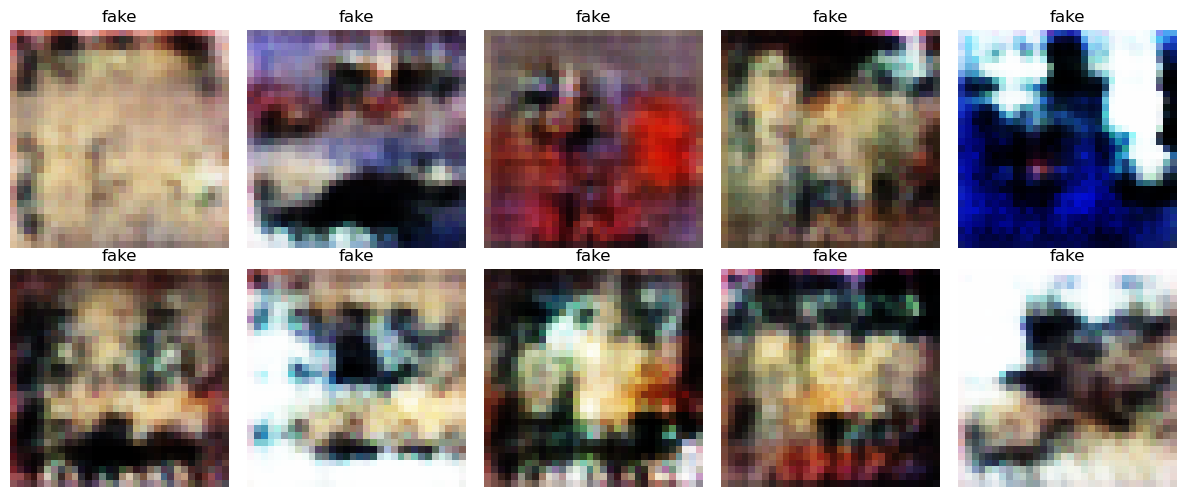

In [73]:
num_show = min(10, fake_images.shape[0])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img in zip(axes.flat, fake_images[:num_show]):
    x = ((img.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)
    if x.shape[0] == 1:
        x = x.repeat(3, 1, 1)
    ax.imshow(x.permute(1, 2, 0).numpy())
    ax.set_title("fake")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [74]:
results = compute_density_coverage(real_features, fake_features, k=K)
print("Real vs Fake:", results)

Real vs Fake: {'density': 0.873046875, 'coverage': 0.416}


In [75]:
real_vs_real = compute_density_coverage(real_features, real_features, k=K)
print("Real vs Real:", real_vs_real)

noise_features = extract_features_from_noise(
    num_batches=FAKE_NUM_BATCHES,
    batch_size=FAKE_BATCH_SIZE,
    channels=num_channels,
)
real_vs_noise = compute_density_coverage(real_features, noise_features, k=K)
print("Real vs Noise:", real_vs_noise)

Real vs Real: {'density': 1.0, 'coverage': 1.0}
Real vs Noise: {'density': 0.0, 'coverage': 0.0}


In [76]:
print("Comparison")
print("-" * 50)
print("Real vs Real :", real_vs_real)
print("Real vs Fake :", results)
print("Real vs Noise:", real_vs_noise)

Comparison
--------------------------------------------------
Real vs Real : {'density': 1.0, 'coverage': 1.0}
Real vs Fake : {'density': 0.873046875, 'coverage': 0.416}
Real vs Noise: {'density': 0.0, 'coverage': 0.0}


In [77]:
for k in [1, 3, 5, 10, 20]:
    rr = compute_density_coverage(real_features, real_features, k=k)
    rf = compute_density_coverage(real_features, fake_features, k=k)
    rn = compute_density_coverage(real_features, noise_features, k=k)

    print(f"k = {k}")
    print("  real-real :", rr)
    print("  real-fake :", rf)
    print("  real-noise:", rn)
    print()

k = 1
  real-real : {'density': 1.0, 'coverage': 1.0}
  real-fake : {'density': 0.828125, 'coverage': 0.142}
  real-noise: {'density': 0.0, 'coverage': 0.0}

k = 3
  real-real : {'density': 1.0, 'coverage': 1.0}
  real-fake : {'density': 0.8079427083333333, 'coverage': 0.308}
  real-noise: {'density': 0.0, 'coverage': 0.0}

k = 5
  real-real : {'density': 1.0, 'coverage': 1.0}
  real-fake : {'density': 0.873046875, 'coverage': 0.416}
  real-noise: {'density': 0.0, 'coverage': 0.0}

k = 10
  real-real : {'density': 1.0, 'coverage': 1.0}
  real-fake : {'density': 0.96015625, 'coverage': 0.59}
  real-noise: {'density': 0.0, 'coverage': 0.0}

k = 20
  real-real : {'density': 1.0, 'coverage': 1.0}
  real-fake : {'density': 1.1231445312500001, 'coverage': 0.8}
  real-noise: {'density': 0.0001953125, 'coverage': 0.002}

